In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sys
sys.path.append("..")
from config import *
from metric import *

In [2]:
def compute_and_print_statistics(df, is_embedding=False):
    rows = []
    
    for algorithm in ALGORITHMS:
        row_data = {'Algorithm': algorithm}
        
        ro_statistics = df.groupby(['type'])[algorithm].agg(['mean', 'std'])
        
        for type_label in ro_statistics.index:
            mean_val = ro_statistics.loc[type_label, 'mean']
            std_val = ro_statistics.loc[type_label, 'std']
            row_data[type_label] = f"{mean_val:.3f} ({std_val:.3f})"
        rows.append(row_data)
    
    results_df = pd.DataFrame(rows)
    if is_embedding:
        # reorder columns since 'text-embedding-3-large' comes first when ordered lexicographically
        results_df = results_df[['Algorithm', 'nomic-embed-text', 'text-embedding-3-small', 'text-embedding-3-large']]
    
    num_cols = len(results_df.columns)
    col_fmt = 'l' + 'r' * (num_cols - 1)
    
    latex_output = results_df.to_latex(index=False, escape=False, column_format=col_fmt)
    print(latex_output)

In [3]:
def calculate_friedman_p(df, alg):
    grouped = df.groupby(['benchmark', 'strong', 'weak', 'type'])[alg].mean()
    pivoted_data = grouped.unstack(level='type')
    
    valid_pairs = pivoted_data.dropna()
    
    if valid_pairs.empty or valid_pairs.shape[1] < 2:
        return 1.0

    try:
        _, p_val = stats.friedmanchisquare(*[valid_pairs[col] for col in valid_pairs.columns])
        return p_val
    except ValueError:
        return 1.0

def compute_and_print_statistics_with_friedman(df, is_embedding=False):
    rows = []
    
    for algorithm in ALGORITHMS:
        row_data = {'Algorithm': algorithm}
        
        ro_statistics = df.groupby(['type'])[algorithm].agg(['mean', 'std'])
        
        for type_label in ro_statistics.index:
            mean_val = ro_statistics.loc[type_label, 'mean']
            std_val = ro_statistics.loc[type_label, 'std']
            row_data[type_label] = f"{mean_val:.3f} ({std_val:.3f})"
        
        p_val = calculate_friedman_p(df, algorithm)
        row_data['p-val'] = f"{p_val:.3f}" if p_val >= 0.001 else "$<$ 0.001"
        rows.append(row_data)
    
    results_df = pd.DataFrame(rows)
    if is_embedding:
        # reorder columns since 'text-embedding-3-large' comes first when ordered lexicographically
        results_df = results_df[['Algorithm', 'nomic-embed-text', 'text-embedding-3-small', 'text-embedding-3-large', 'p-val']]
    
    num_cols = len(results_df.columns)
    col_fmt = 'l' + 'r' * (num_cols - 1)
    
    latex_output = results_df.to_latex(index=False, escape=False, column_format=col_fmt)
    print(latex_output)

## RQ3-1 Does the selection of the specific Transformer layer for state extraction influence router performance?

In [4]:
testing_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}.csv', index_col=0)
testing_df = testing_df[testing_df['input'] == 'internal state']
compute_and_print_statistics(testing_df)

\begin{tabular}{lrrr}
\toprule
Algorithm & 1/2 & 2/3 & 3/4 \\
\midrule
Logistic Regression & 0.541 (0.055) & 0.538 (0.055) & 0.543 (0.053) \\
SVM & 0.511 (0.047) & 0.511 (0.048) & 0.515 (0.050) \\
MLP & 0.538 (0.042) & 0.543 (0.053) & 0.542 (0.046) \\
Ensemble & 0.539 (0.050) & 0.539 (0.056) & 0.543 (0.053) \\
RouteLLM & 0.547 (0.048) & 0.540 (0.050) & 0.545 (0.053) \\
\bottomrule
\end{tabular}



In [5]:
compute_and_print_statistics_with_friedman(testing_df)

\begin{tabular}{lrrrr}
\toprule
Algorithm & 1/2 & 2/3 & 3/4 & p-val \\
\midrule
Logistic Regression & 0.541 (0.055) & 0.538 (0.055) & 0.543 (0.053) & 0.458 \\
SVM & 0.511 (0.047) & 0.511 (0.048) & 0.515 (0.050) & 0.571 \\
MLP & 0.538 (0.042) & 0.543 (0.053) & 0.542 (0.046) & 0.423 \\
Ensemble & 0.539 (0.050) & 0.539 (0.056) & 0.543 (0.053) & 0.607 \\
RouteLLM & 0.547 (0.048) & 0.540 (0.050) & 0.545 (0.053) & 0.023 \\
\bottomrule
\end{tabular}



In [6]:
code_gen_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}_codegen.csv', index_col=0)
code_gen_df = code_gen_df[code_gen_df['input'] == 'internal state']
compute_and_print_statistics_with_friedman(code_gen_df)

\begin{tabular}{lrrrr}
\toprule
Algorithm & 1/2 & 2/3 & 3/4 & p-val \\
\midrule
Logistic Regression & 0.648 (0.148) & 0.670 (0.146) & 0.674 (0.134) & 0.004 \\
SVM & 0.649 (0.143) & 0.667 (0.145) & 0.657 (0.150) & 0.549 \\
MLP & 0.627 (0.114) & 0.644 (0.113) & 0.652 (0.093) & 0.043 \\
Ensemble & 0.654 (0.138) & 0.673 (0.141) & 0.683 (0.127) & 0.035 \\
RouteLLM & 0.639 (0.124) & 0.645 (0.106) & 0.654 (0.100) & 0.043 \\
\bottomrule
\end{tabular}



## RQ3-2. Does the choice of embedding model influence router performance?

In [7]:
testing_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}.csv', index_col=0)
testing_df = testing_df[testing_df['input'] == 'prompt embedding']
compute_and_print_statistics(testing_df, is_embedding=True)

\begin{tabular}{lrrr}
\toprule
Algorithm & nomic-embed-text & text-embedding-3-small & text-embedding-3-large \\
\midrule
Logistic Regression & 0.502 (0.040) & 0.519 (0.051) & 0.520 (0.051) \\
SVM & 0.490 (0.039) & 0.499 (0.045) & 0.499 (0.045) \\
MLP & 0.508 (0.038) & 0.524 (0.042) & 0.523 (0.045) \\
Ensemble & 0.505 (0.041) & 0.521 (0.048) & 0.521 (0.050) \\
RouteLLM & 0.509 (0.034) & 0.521 (0.040) & 0.520 (0.039) \\
\bottomrule
\end{tabular}



In [8]:
compute_and_print_statistics_with_friedman(testing_df, is_embedding=True)

\begin{tabular}{lrrrr}
\toprule
Algorithm & nomic-embed-text & text-embedding-3-small & text-embedding-3-large & p-val \\
\midrule
Logistic Regression & 0.502 (0.040) & 0.519 (0.051) & 0.520 (0.051) & 0.127 \\
SVM & 0.490 (0.039) & 0.499 (0.045) & 0.499 (0.045) & 0.538 \\
MLP & 0.508 (0.038) & 0.524 (0.042) & 0.523 (0.045) & 0.053 \\
Ensemble & 0.505 (0.041) & 0.521 (0.048) & 0.521 (0.050) & 0.053 \\
RouteLLM & 0.509 (0.034) & 0.521 (0.040) & 0.520 (0.039) & 0.034 \\
\bottomrule
\end{tabular}



In [9]:
code_gen_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}_codegen.csv', index_col=0)
code_gen_df = code_gen_df[code_gen_df['input'] == 'prompt embedding']
compute_and_print_statistics_with_friedman(code_gen_df, is_embedding=True)

\begin{tabular}{lrrrr}
\toprule
Algorithm & nomic-embed-text & text-embedding-3-small & text-embedding-3-large & p-val \\
\midrule
Logistic Regression & 0.576 (0.097) & 0.608 (0.107) & 0.608 (0.107) & 0.022 \\
SVM & 0.596 (0.110) & 0.608 (0.101) & 0.609 (0.101) & 0.819 \\
MLP & 0.604 (0.092) & 0.616 (0.069) & 0.623 (0.073) & 0.259 \\
Ensemble & 0.598 (0.097) & 0.623 (0.099) & 0.631 (0.100) & 0.165 \\
RouteLLM & 0.599 (0.068) & 0.625 (0.069) & 0.625 (0.069) & 0.004 \\
\bottomrule
\end{tabular}



## RQ3-1 & 3-2 Boxplot

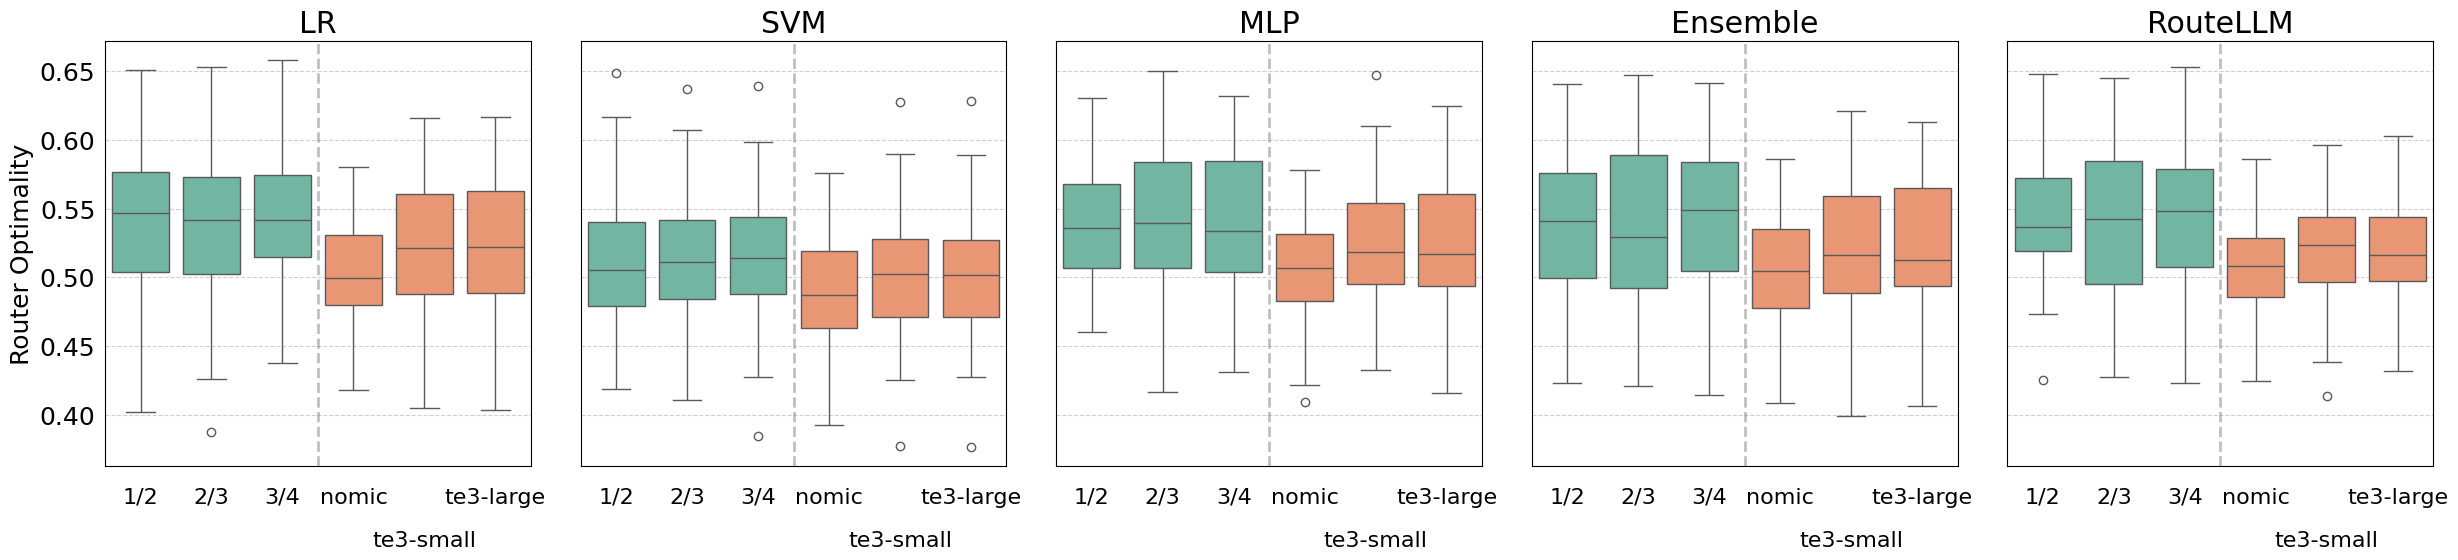

In [10]:
plt.rcParams.update({'font.size': 18})

testing_df = pd.read_csv(f'metrics/router_optimality_{DEFAULT_PROMPT_TYPE}.csv', index_col=0)

plot_order = ['1/2', '2/3', '3/4',
              'nomic-embed-text', 'text-embedding-3-small', 'text-embedding-3-large']

c1 = plt.get_cmap('Set2').colors[0]
c2 = plt.get_cmap('Set2').colors[1]
palette = {
    '1/2': c1, '2/3': c1, '3/4': c1, 
    'nomic-embed-text': c2, 
    'text-embedding-3-small': c2, 
    'text-embedding-3-large': c2
}

fig, axes = plt.subplots(1, len(ALGORITHMS), figsize=(5 * len(ALGORITHMS), 6), sharey=True)

for alg, ax in zip(ALGORITHMS, axes):
    sns.boxplot(data=testing_df, x='type', y=alg, ax=ax,
                order=plot_order, palette=palette, hue='type', legend=False)

    ax.set_title(alg if alg != 'Logistic Regression' else 'LR')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    
    ax.set_xlabel('')
    ax.set_xticks([])
    
    ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)

    labels_map = {
        0: '1/2', 1: '2/3', 2: '3/4',
        3: 'nomic', 
        4: 'te3-small', 
        5: 'te3-large'
    }

global_default_y = None
global_staggered_y = None

for ax in axes:
    y_lims = ax.get_ylim()
    y_range = y_lims[1] - y_lims[0]
    default_y = y_lims[0] - y_range * 0.05
    staggered_y = y_lims[0] - y_range * 0.15
    
    if not global_default_y or global_default_y > default_y:
        global_default_y = default_y
    if not global_staggered_y or global_staggered_y > staggered_y:
        global_staggered_y = staggered_y

for ax in axes:
    for idx, label in labels_map.items():
        y_pos = global_staggered_y if label == 'te3-small' else global_default_y
        ax.text(idx, y_pos, label, ha='center', va='top', fontsize=16)

    ax.set_ylabel('Router Optimality', fontsize=18)
    
    ax.tick_params(axis='y', left=False)

plt.tight_layout()
plt.savefig(f'figures/RQ3_input_comparison.pdf')